# El dataset, mirado antes de modelar

`competencia_01.parquet`: una fila por (cliente, mes), 983.061 filas, 169.727 clientes, 202103–202108, 154 campos del
banco más `clase_ternaria` (construida mirando dos meses adelante) y las columnas de baja a nivel cliente que agrega
`v001` (`es_baja`, `k` = meses hasta la última foto). Todo se calcula con DuckDB sobre el parquet; nada se imputa.

In [1]:
import sys, re, textwrap
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
sys.path.insert(0, str(Path("../src").resolve()))
import v_estilo as ve
ve.aplicar()
mpl.rcParams.update({"font.size": 12, "axes.titlesize": 16, "legend.fontsize": 11, "figure.dpi": 100})
AZUL, NARANJA, AQUA, AMARILLO = ve.SERIES

def sin_marco(ax):
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.tick_params(length=0)
    ax.grid(axis="y", color=ve.GRILLA, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

import duckdb
con = duckdb.connect()
con.execute("create view d as select * from read_parquet('../data/competencia_01.parquet')")
def q(sql): return con.execute(sql).df()
MESES = [202103, 202104, 202105, 202106, 202107, 202108]
ETQ = {202103: "mar", 202104: "abr", 202105: "may", 202106: "jun", 202107: "jul", 202108: "ago"}

## 1. La cartera no es cerrada

Cada mes entran clientes al paquete (primera foto) y salen otros (última foto). El stock crece. Decir "perdemos mil por
mes" sin decir que entran mil cuatrocientos es contar la mitad.

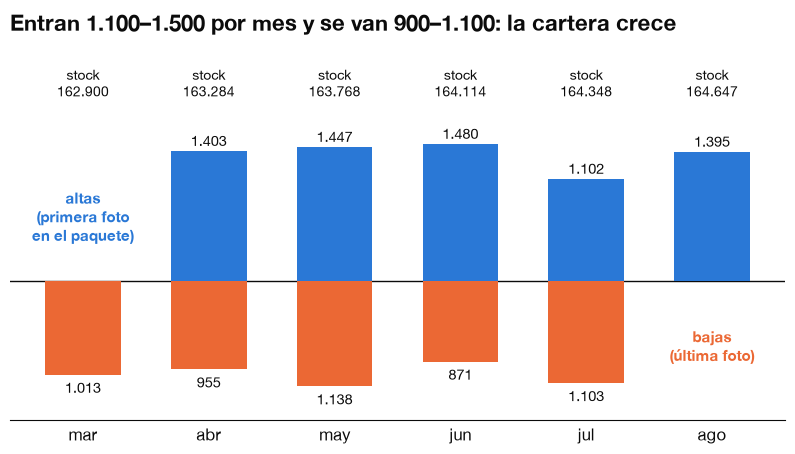

In [2]:
flujo = q("""
with v as (select numero_de_cliente, min(foto_mes) m0, max(foto_mes) m1 from d group by 1)
select foto_mes,
       count(*) as stock,
       (select count(*) from v where v.m0 = x.foto_mes and x.foto_mes > 202103) as altas,
       (select count(*) from v where v.m1 = x.foto_mes and x.foto_mes < 202108) as bajas
from d x group by 1 order by 1""")
fig, ax = plt.subplots(figsize=(10, 4.8))
x = np.arange(len(flujo))
ax.bar(x, flujo.altas, color=AZUL, width=0.6, zorder=3, label="altas (primera foto)")
ax.bar(x, -flujo.bajas, color=NARANJA, width=0.6, zorder=3, label="bajas (última foto)")
for xi, a, b, s in zip(x, flujo.altas, flujo.bajas, flujo.stock):
    if a: ax.annotate(ve.num(a), (xi, a), xytext=(0, 4), textcoords="offset points", ha="center", fontsize=10.5)
    if b: ax.annotate(ve.num(b), (xi, -b), xytext=(0, -13), textcoords="offset points", ha="center", fontsize=10.5)
    ax.text(xi, 2000, f"stock\n{ve.num(s)}", ha="center", fontsize=10, color=ve.TINTA)
ax.axhline(0, color=ve.TINTA, linewidth=1)
ax.set_xticks(x, [ETQ[m] for m in flujo.foto_mes]); ax.set_ylim(-1500, 2500); ax.set_yticks([])
ax.text(0, 700, "altas\n(primera foto\nen el paquete)", color=AZUL, fontsize=11, fontweight="bold", ha="center", va="center")
ax.text(5, -700, "bajas\n(última foto)", color=NARANJA, fontsize=11, fontweight="bold", ha="center", va="center")
ax.set_title("Entran 1.100–1.500 por mes y se van 900–1.100: la cartera crece")
for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
ax.tick_params(length=0); 
plt.show()

## 2. Los nulos vienen en bloques

Un nulo acá no es "falta el dato": es "no tiene ese producto". Las columnas con nulos se agrupan en pocos bloques
que se repiten mes a mes con el mismo porcentaje (Master ~59%, Visa ~13%, y dos bloques chicos). Imputar con la
mediana le inventaría una tarjeta a más de la mitad de la cartera.

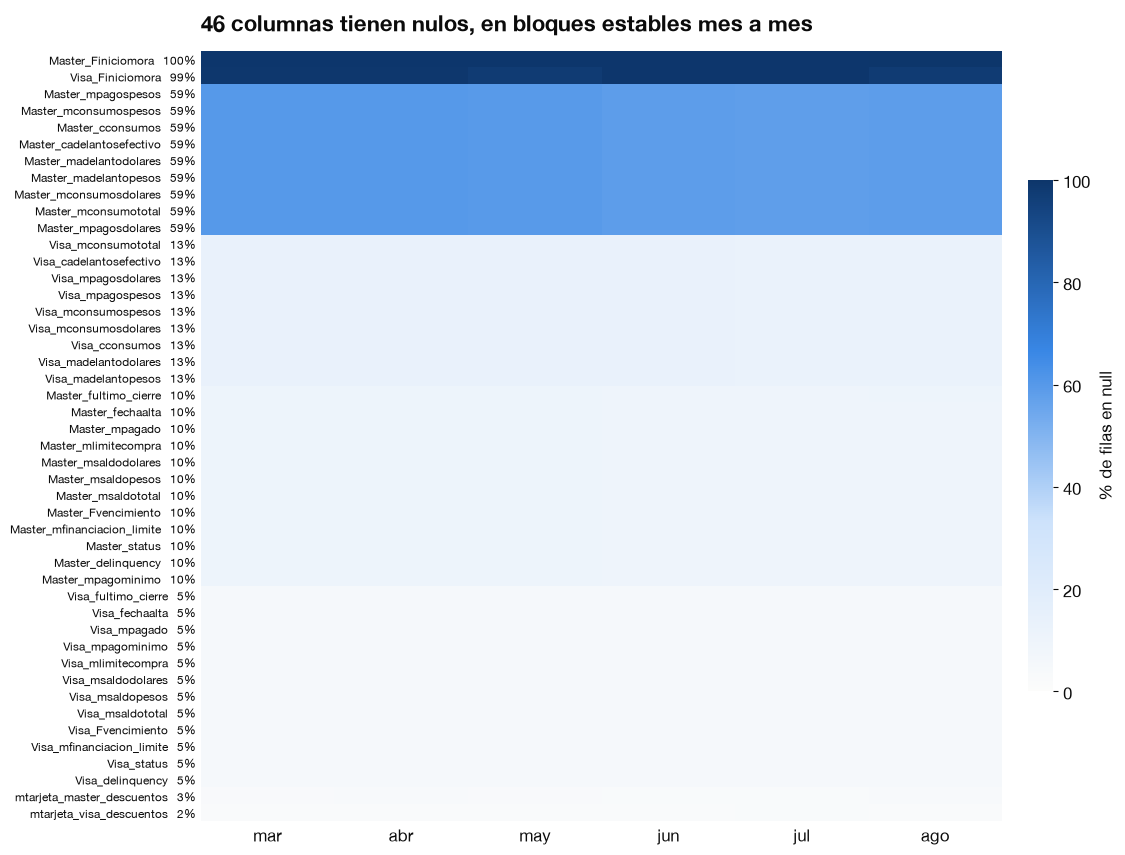

In [3]:
cols = [c for c, t in con.execute("describe d").fetchall()[:2] and con.execute("describe d").df()[["column_name", "column_type"]].itertuples(index=False)
        if c not in ("numero_de_cliente", "foto_mes", "clase_ternaria", "mes_ultimo", "mes_baja", "es_baja", "k", "meses_historia")]
nulos = q("select foto_mes, " + ", ".join(f'avg(case when "{c}" is null then 1 else 0 end) as "{c}"' for c in cols) + " from d group by 1 order by 1").set_index("foto_mes")
nulos = nulos.loc[:, (nulos > 0).any()]
orden = nulos.mean().sort_values(ascending=False).index
nulos = nulos[orden]
fig, ax = plt.subplots(figsize=(11, 10))
im = ax.imshow(nulos.T.to_numpy() * 100, aspect="auto", cmap=mpl.colors.LinearSegmentedColormap.from_list("b", ["#fcfcfb", "#cde2fb", "#3987e5", "#0d366b"]), vmin=0, vmax=100)
ax.set_yticks(range(len(orden)), [f"{c}   {nulos[c].mean() * 100:.0f}%" for c in orden], fontsize=8.5)
ax.set_xticks(range(6), [ETQ[m] for m in nulos.index])
cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.03); cb.set_label("% de filas en null"); cb.outline.set_visible(False)
ax.set_title(f"{len(orden)} columnas tienen nulos, en bloques estables mes a mes")
ax.tick_params(length=0)
for s in ax.spines.values(): s.set_visible(False)
plt.show()

## 3. Los pesos no son comparables entre meses

Mediana mensual de algunos montos entre quienes tienen valor distinto de cero, indexada a marzo = 100. La inflación
mueve todo hacia arriba; la comisión de mantenimiento salta en julio y agosto porque el banco cambió el precio.

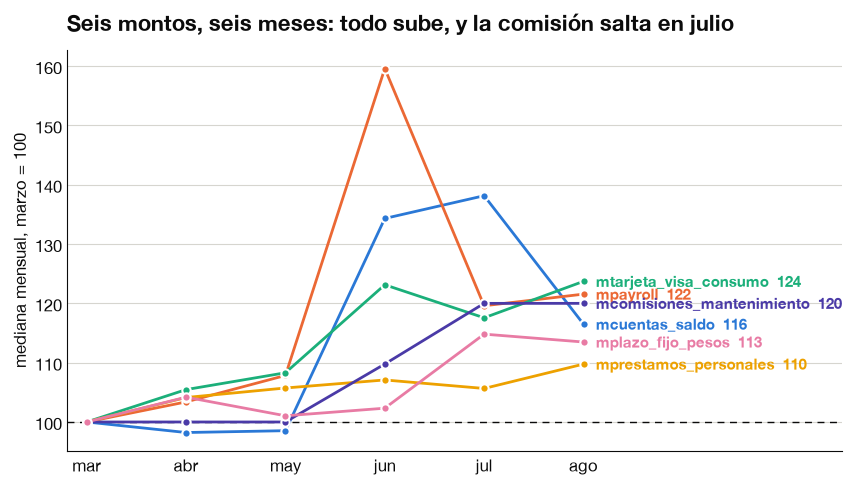

In [4]:
mon = ["mcuentas_saldo", "mpayroll", "mtarjeta_visa_consumo", "mprestamos_personales", "mcomisiones_mantenimiento", "mplazo_fijo_pesos"]
med = q("select foto_mes, " + ", ".join(f"median(case when {c} <> 0 then abs({c}) end) as {c}" for c in mon) + " from d group by 1 order by 1").set_index("foto_mes")
idx = med / med.iloc[0] * 100
fig, ax = plt.subplots(figsize=(10, 5.2))
colores = [AZUL, NARANJA, AQUA, AMARILLO, "#4a3aa7", "#e87ba4"]
for c, col in zip(mon, colores):
    ax.plot(range(6), idx[c], color=col, linewidth=2, marker="o", markersize=6, markeredgecolor="white", markeredgewidth=1.5, zorder=3)
    ax.annotate(f" {c}  {idx[c].iloc[-1]:.0f}", (5, idx[c].iloc[-1]), xytext=(6, 0), textcoords="offset points", va="center", fontsize=10.5, color=col, fontweight="bold")
ax.axhline(100, color=ve.TINTA, linewidth=1, linestyle=(0, (5, 4)))
ax.set_xticks(range(6), [ETQ[m] for m in idx.index]); ax.set_ylabel("mediana mensual, marzo = 100"); ax.set_xlim(-0.2, 7.6)
ax.set_title("Seis montos, seis meses: todo sube, y la comisión salta en julio")
sin_marco(ax); 
plt.show()

## 4. Lo que se rompe en un solo mes

Porcentaje de clientes con cada condición, por mes. `ccajas_depositos` es todo cero en mayo (y casi todo cero en
junio); `Visa_Finiciomora` tiene ceros inyectados en mayo y agosto; `cpayroll_trx > 1` salta en junio por el
aguinaldo. Son artefactos del proceso, no conducta, y dos caen en el mes a predecir.

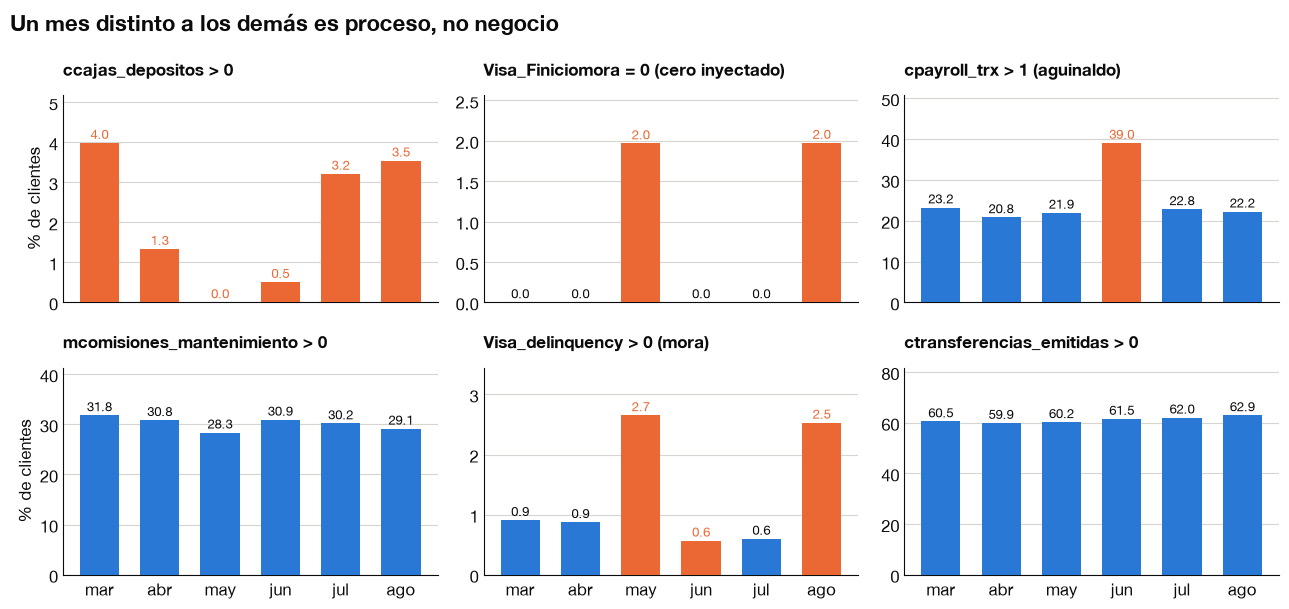

In [5]:
cond = {"ccajas_depositos > 0": "ccajas_depositos > 0", "Visa_Finiciomora = 0 (cero inyectado)": "Visa_Finiciomora = 0",
        "cpayroll_trx > 1 (aguinaldo)": "cpayroll_trx > 1", "mcomisiones_mantenimiento > 0": "mcomisiones_mantenimiento > 0",
        "Visa_delinquency > 0 (mora)": "Visa_delinquency > 0", "ctransferencias_emitidas > 0": "ctransferencias_emitidas > 0"}
t = q("select foto_mes, " + ", ".join(f'100.0 * avg(case when {e} then 1 else 0 end) as "{k}"' for k, e in cond.items()) + " from d group by 1 order by 1").set_index("foto_mes")
fig, axs = plt.subplots(2, 3, figsize=(13, 6.2), sharex=True)
for ax, (k, serie) in zip(axs.ravel(), t.items()):
    raro = (serie - serie.median()).abs() > max(0.25 * serie.median(), 0.3)
    ax.bar(range(6), serie, color=[NARANJA if r else AZUL for r in raro], width=0.65, zorder=3)
    for i, (val, r) in enumerate(zip(serie, raro)):
        ax.annotate(f"{val:.1f}", (i, val), xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9.5, color=NARANJA if r else ve.TINTA)
    ax.set_title(k, fontsize=12); ax.set_xticks(range(6), [ETQ[m] for m in t.index]); ax.set_ylim(0, serie.max() * 1.3)
    sin_marco(ax)
axs[0, 0].set_ylabel("% de clientes"); axs[1, 0].set_ylabel("% de clientes")
fig.suptitle("Un mes distinto a los demás es proceso, no negocio", x=0.01, ha="left", fontsize=16, fontweight="bold")
fig.tight_layout(); 
plt.show()

## 5. La señal más fuerte: actividad y saldo en rojo

Izquierda: distribución acumulada de `ctrx_quarter` (movimientos voluntarios en cuentas, 90 días) para los que se
quedan y los que se van en dos meses. Derecha: porcentaje con la cuenta en rojo, por clase y por mes: la brecha es
estable, no es un artefacto de un mes.

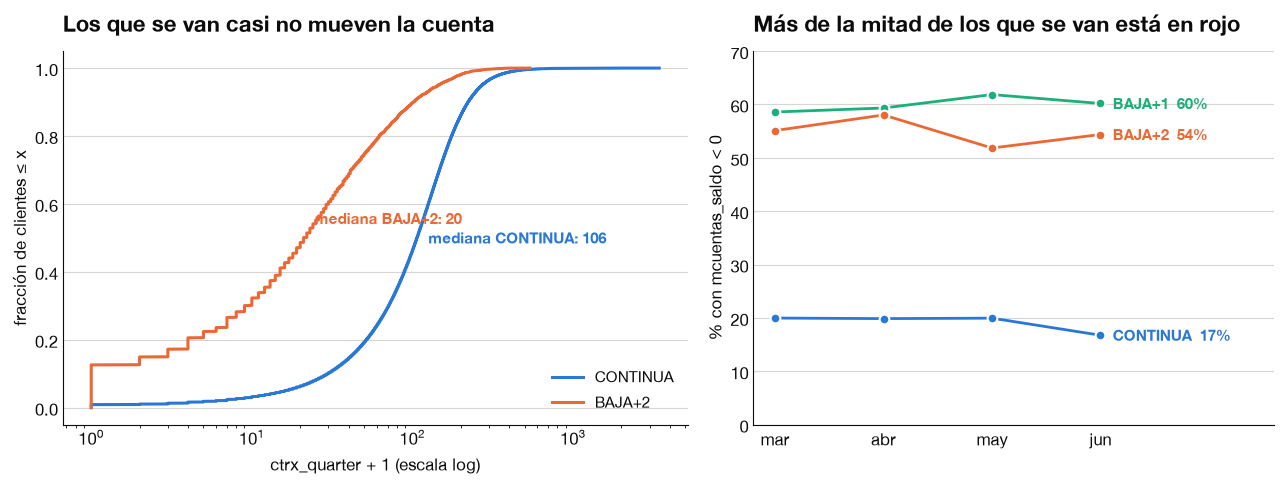

In [6]:
ecdf = q("select clase_ternaria, ctrx_quarter from d where foto_mes between 202103 and 202106 and clase_ternaria in ('CONTINUA','BAJA+2')")
rojo = q("""select foto_mes, clase_ternaria, 100.0 * avg(case when mcuentas_saldo < 0 then 1 else 0 end) as rojo
            from d where foto_mes between 202103 and 202106 group by 1, 2 order by 1, 2""").pivot(index="foto_mes", columns="clase_ternaria", values="rojo")
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1.2, 1]})
for clase, col in (("CONTINUA", AZUL), ("BAJA+2", NARANJA)):
    xs = np.sort(ecdf[ecdf.clase_ternaria == clase].ctrx_quarter.to_numpy()); ys = np.arange(1, len(xs) + 1) / len(xs)
    a1.plot(xs + 1, ys, color=col, linewidth=2.2, label=clase)
    med = np.median(xs); a1.annotate(f"mediana {clase}: {med:.0f}", (med + 1, 0.5), xytext=(8, -4 if clase == "CONTINUA" else 10), textcoords="offset points", color=col, fontsize=10.5, fontweight="bold")
a1.set_xscale("log"); a1.set_xlabel("ctrx_quarter + 1 (escala log)"); a1.set_ylabel("fracción de clientes ≤ x")
a1.legend(loc="lower right", frameon=False); a1.set_title("Los que se van casi no mueven la cuenta"); sin_marco(a1)
for clase, col in (("CONTINUA", AZUL), ("BAJA+1", AQUA), ("BAJA+2", NARANJA)):
    a2.plot(range(4), rojo[clase], color=col, linewidth=2, marker="o", markersize=7, markeredgecolor="white", markeredgewidth=1.5)
    a2.annotate(f" {clase}  {rojo[clase].iloc[-1]:.0f}%", (3, rojo[clase].iloc[-1]), xytext=(6, 0), textcoords="offset points", va="center", color=col, fontsize=10.5, fontweight="bold")
a2.set_xticks(range(4), [ETQ[m] for m in rojo.index]); a2.set_xlim(-0.2, 4.6); a2.set_ylabel("% con mcuentas_saldo < 0"); a2.set_ylim(0, 70)
a2.set_title("Más de la mitad de los que se van está en rojo"); sin_marco(a2)
fig.tight_layout(); 
plt.show()

## 6. Cómo se ve la baja meses antes (y qué llega demasiado tarde)

Para los clientes que se fueron (`es_baja`), cada variable por `k` = meses antes de la última foto, contra la base de
los que siguen. La actividad y el rojo avisan con meses de anticipación; el cierre de la tarjeta Visa (`Visa_status`
6/7/9) recién aparece en la última foto: un modelo a dos meses casi no lo ve, y si lo ve mucho es *leakage*.

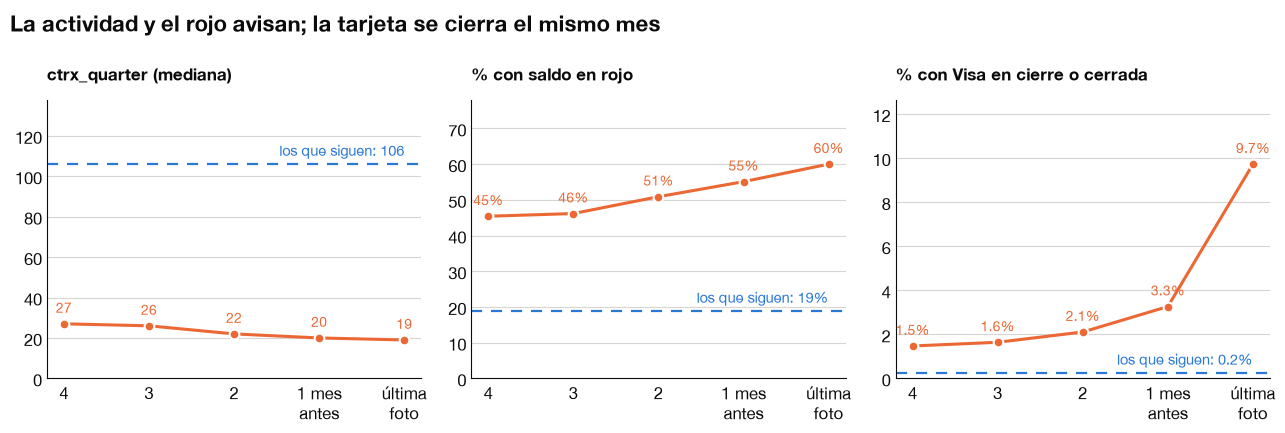

In [7]:
traj = q("""select k, median(ctrx_quarter) as ctrx, 100.0*avg(case when mcuentas_saldo < 0 then 1 else 0 end) as rojo,
                   100.0*avg(case when Visa_status in (6,7,9) then 1 else 0 end) as visa_cerrada, count(*) n
            from d where es_baja and k <= 4 group by 1 order by 1""")
base = q("""select median(ctrx_quarter) as ctrx, 100.0*avg(case when mcuentas_saldo < 0 then 1 else 0 end) as rojo,
                   100.0*avg(case when Visa_status in (6,7,9) then 1 else 0 end) as visa_cerrada
            from d where not es_baja and foto_mes between 202103 and 202106""").iloc[0]
fig, axs = plt.subplots(1, 3, figsize=(13, 4.4))
for ax, (col, titulo, fmt) in zip(axs, (("ctrx", "ctrx_quarter (mediana)", "{:.0f}"), ("rojo", "% con saldo en rojo", "{:.0f}%"), ("visa_cerrada", "% con Visa en cierre o cerrada", "{:.1f}%"))):
    ax.plot(traj.k, traj[col], color=NARANJA, linewidth=2.2, marker="o", markersize=7, markeredgecolor="white", markeredgewidth=1.5, zorder=3)
    ax.axhline(base[col], color=AZUL, linewidth=1.6, linestyle=(0, (5, 4)))
    ax.annotate(f"los que siguen: {fmt.format(base[col])}", (0, base[col]), xytext=(0, 6), textcoords="offset points", ha="right", color=AZUL, fontsize=10.5)
    for kk, val in zip(traj.k, traj[col]):
        ax.annotate(fmt.format(val), (kk, val), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=10, color=NARANJA)
    ax.set_xticks(range(5), ["última\nfoto", "1 mes\nantes", "2", "3", "4"]); ax.set_title(titulo, fontsize=12.5); ax.invert_xaxis()
    ax.set_ylim(0, max(traj[col].max(), base[col]) * 1.3); sin_marco(ax)
fig.suptitle("La actividad y el rojo avisan; la tarjeta se cierra el mismo mes", x=0.01, ha="left", fontsize=16, fontweight="bold")
fig.tight_layout(); 
plt.show()

## 7. Cada variable sola, contra BAJA+2

AUC univariado de cada columna numérica contra BAJA+2 en los cuatro meses etiquetados (nulos al mínimo, que es
"no tiene"). Se grafica la distancia a 0,5; el color dice en qué dirección: más alto → más baja, o más bajo → más baja.
Ninguna variable sola pasa de 0,70: por eso el modelo necesita cientos.

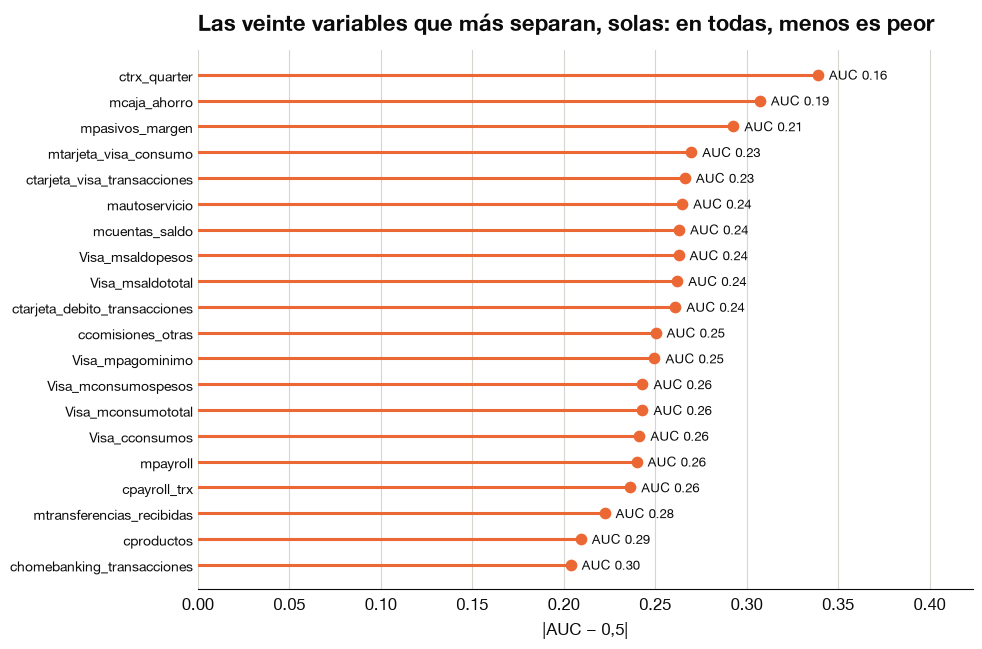

In [8]:
from sklearn.metrics import roc_auc_score
cols_num = [c for c, t in con.execute("describe d").df()[["column_name", "column_type"]].itertuples(index=False)
            if t not in ("VARCHAR", "BOOLEAN") and c not in ("numero_de_cliente", "foto_mes", "mes_ultimo", "mes_baja", "k", "meses_historia")]
lab = q("select * from d where foto_mes between 202103 and 202106")
y = (lab.clase_ternaria == "BAJA+2").to_numpy()
aucs = {}
for c in cols_num:
    x = lab[c].to_numpy(dtype="float64"); x = np.where(np.isnan(x), np.nanmin(x) - 1 if np.isfinite(np.nanmin(x)) else 0, x)
    if np.ptp(x) == 0: continue
    aucs[c] = roc_auc_score(y, x)
a = pd.Series(aucs); d2 = (a - 0.5).abs().sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(10, 7))
for i, c in enumerate(d2.index[::-1]):
    col = NARANJA if a[c] < 0.5 else AZUL
    ax.plot([0, d2[c]], [i, i], color=col, linewidth=2.2, solid_capstyle="round"); ax.scatter([d2[c]], [i], color=col, s=55, zorder=3)
    ax.annotate(f"AUC {a[c]:.2f}", (d2[c], i), xytext=(8, 0), textcoords="offset points", va="center", fontsize=9.5)
ax.set_yticks(range(len(d2)), d2.index[::-1], fontsize=10); ax.set_xlabel("|AUC − 0,5|"); ax.set_xlim(0, d2.max() * 1.25)
if (a[d2.index] > 0.5).any():
    ax.plot([], [], color=NARANJA, linewidth=3, label="más bajo → más baja"); ax.plot([], [], color=AZUL, linewidth=3, label="más alto → más baja")
    ax.legend(loc="lower right", frameon=False)
ax.set_title("Las veinte variables que más separan, solas: en todas, menos es peor")
for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
ax.tick_params(length=0); ax.grid(axis="x", color=ve.GRILLA, linewidth=0.8, zorder=0); ax.set_axisbelow(True)
plt.show()

## 8. Las variables se mueven despacio

Correlación de cada variable con su propio valor del mes anterior (sobre `competencia_01_lags12.parquet`, que ya
tiene el lag). La mayoría está arriba de 0,9: el lag casi repite la variable, y lo que aporta información es el
**delta**, no el nivel pasado. Y aun así, agregar lags y deltas fue lo que más movió el público.

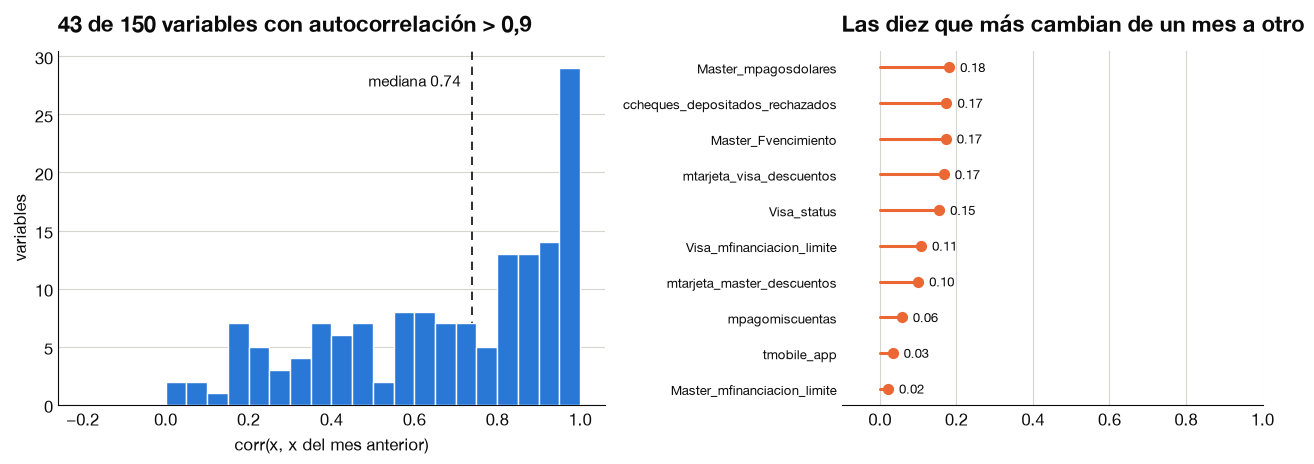

In [9]:
con.execute("create view l as select * from read_parquet('../data/competencia_01_lags12.parquet')")
bases = [c for c, in con.execute("describe l").fetchall() and [(r[0],) for r in con.execute("describe l").fetchall()] if not c.endswith(("__lag1", "__lag2", "__delta1", "__delta2")) and c not in ("numero_de_cliente", "foto_mes", "clase_ternaria")]
bases = [c for c in bases if f"{c}__lag1" in {r[0] for r in con.execute("describe l").fetchall()}]
rho = q("select " + ", ".join(f'corr("{c}", "{c}__lag1") as "{c}"' for c in bases) + " from l where foto_mes >= 202104").iloc[0].dropna().sort_values()
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={"width_ratios": [1.3, 1]})
a1.hist(rho, bins=np.linspace(-0.2, 1, 25), color=AZUL, edgecolor="white", zorder=3)
a1.axvline(rho.median(), color=ve.TINTA, linewidth=1.2, linestyle=(0, (5, 4)))
a1.annotate(f"mediana {rho.median():.2f}", (rho.median(), a1.get_ylim()[1] * 0.9), xytext=(-8, 0), textcoords="offset points", ha="right", fontsize=11)
a1.set_xlabel("corr(x, x del mes anterior)"); a1.set_ylabel("variables"); a1.set_title(f"{(rho > 0.9).sum()} de {len(rho)} variables con autocorrelación > 0,9"); sin_marco(a1)
bajas = rho.head(10)
for i, (c, r) in enumerate(bajas.items()):
    a2.plot([0, r], [i, i], color=NARANJA, linewidth=2.2, solid_capstyle="round"); a2.scatter([r], [i], color=NARANJA, s=50, zorder=3)
    a2.annotate(f"{r:.2f}", (r, i), xytext=(8, 0), textcoords="offset points", va="center", fontsize=9.5)
a2.set_yticks(range(len(bajas)), bajas.index, fontsize=9.5); a2.set_xlim(-0.1, 1); a2.set_title("Las diez que más cambian de un mes a otro")
for s in ("top", "right", "left"): a2.spines[s].set_visible(False)
a2.tick_params(length=0); a2.grid(axis="x", color=ve.GRILLA, linewidth=0.8, zorder=0); a2.set_axisbelow(True)
fig.tight_layout(); 
plt.show()